# Notebook 3 — Rent Burden & Cancer SDOH Analysis

**TruBridge Externship | Iowa Colorectal Cancer (2016–2020)**

Analyzes housing cost burden (ACS Table B25070) vs late-stage colorectal cancer across Iowa counties.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd                          # choropleth maps
from scipy.stats import pearsonr


## 1. Load cancer registry data

> **Colab:** Upload all CSV files via the folder icon before running.

In [2]:
# ── Upload: county_colorectal_latestage_2016-2020.csv ────────────────────────
cancer_df = pd.read_csv('county_colorectal_latestage_2016-2020.csv')
cancer_df.rename(columns={'identifier':'County','AAR':'Number of New Cases per 100K',
                           'AARprob':'Cancer Risk Probability'}, inplace=True)
cancer_df.drop(columns='AARsd', inplace=True)
cancer_df.sort_values('County', inplace=True)
cancer_df.reset_index(drop=True, inplace=True)
cancer_df.columns = cancer_df.columns.str.strip()
assert len(cancer_df) == 99, f"Expected 99 counties, got {len(cancer_df)}"
print(f"Cancer data: {len(cancer_df)} counties | "
      f"Cancer Risk Probability range: {cancer_df['Cancer Risk Probability'].min():.4f}–{cancer_df['Cancer Risk Probability'].max():.4f}")
cancer_df.head()


Cancer data: 99 counties | Cancer Risk Probability range: 0.0100–0.5700


,County,Number of New Cases per 100K,Cancer Risk Probability,mapPop
0,Adair,18.99,0.25,5.2005
1,Adams,18.90,0.23,3.6579
2,Allamakee,18.15,0.11,8.3985
3,Appanoose,19.28,0.33,9.6327
4,Audubon,19.13,0.29,5.3292


## 2. Extract and prepare rent burden SDOH data

In [3]:
# ── Upload: ACS - B25070 - Gross Rent as Percent Household in IA - 2020 5 Yr Estimate (2016-20).csv
rent_raw = pd.read_csv('ACS - B25070 - Gross Rent as Percent Household in IA - 2020 5 Yr Estimate (2016-20).csv')

est_cols     = [c for c in rent_raw.columns if 'Estimate' in c]
county_names = [c.replace(' County, Iowa!!Estimate','').strip() for c in est_cols]
rent_cats    = rent_raw['Label (Grouping)'].tolist()

rows = []
for i, ecol in enumerate(est_cols):
    d = {'County': county_names[i]}
    for j, cat in enumerate(rent_cats):
        d[cat.strip().replace('\xa0','').strip()] = rent_raw[ecol].iloc[j]
    rows.append(d)
rent_df = pd.DataFrame(rows)

num_cols = ['Total:','Less than 10.0 percent','10.0 to 14.9 percent','15.0 to 19.9 percent',
            '20.0 to 24.9 percent','25.0 to 29.9 percent','30.0 to 34.9 percent',
            '35.0 to 39.9 percent','40.0 to 49.9 percent','50.0 percent or more','Not computed']
for col in num_cols:
    rent_df[col] = pd.to_numeric(rent_df[col].astype(str).str.replace(',',''), errors='coerce')

tot = rent_df['Total:']
rent_df['pct_Rent_Affordable_Under_30pct'] = (
    rent_df[['Less than 10.0 percent','10.0 to 14.9 percent','15.0 to 19.9 percent',
             '20.0 to 24.9 percent','25.0 to 29.9 percent']].sum(axis=1) / tot * 100)
rent_df['pct_Rent_Burdened_30pct_Plus'] = (
    rent_df[['30.0 to 34.9 percent','35.0 to 39.9 percent',
             '40.0 to 49.9 percent','50.0 percent or more']].sum(axis=1) / tot * 100)
rent_df['pct_Severely_Rent_Burdened'] = rent_df['50.0 percent or more'] / tot * 100

rent_vars   = ['pct_Rent_Affordable_Under_30pct','pct_Rent_Burdened_30pct_Plus','pct_Severely_Rent_Burdened']
cancer_vars = ['Number of New Cases per 100K','Cancer Risk Probability']

merged_rent = rent_df.merge(cancer_df, on='County', how='inner')
merged_rent.to_csv('iowa_colorectal_cancer_rent_sdoh_2016-2020.csv', index=False)

print(f"Merged: {len(merged_rent)} counties (expected 99)")
print("Missing values in rent columns:")
print(merged_rent[rent_vars].isnull().sum().to_string())
if (rent_df['Total:'] == 0).any():
    print(f"WARNING: {(rent_df['Total:']==0).sum()} counties have Total:=0 — check those rows")
merged_rent[['County'] + rent_vars + cancer_vars].head()


Merged: 99 counties (expected 99)
Missing values in rent columns:
pct_Rent_Affordable_Under_30pct    0
pct_Rent_Burdened_30pct_Plus       0
pct_Severely_Rent_Burdened         0


,County,pct_Rent_Affordable_Under_30pct,pct_Rent_Burdened_30pct_Plus,pct_Severely_Rent_Burdened,Number of New Cases per 100K,Cancer Risk Probability
0,Adair,61.840745,22.130300,13.133402,18.99,0.25
1,Adams,63.461538,16.666667,1.602564,18.90,0.23
2,Allamakee,55.283178,28.064243,19.188504,18.15,0.11
3,Appanoose,43.654114,38.702929,19.665272,19.28,0.33
4,Audubon,54.761905,33.779762,21.428571,19.13,0.29


## 3. Geographic overview, distributions and correlations

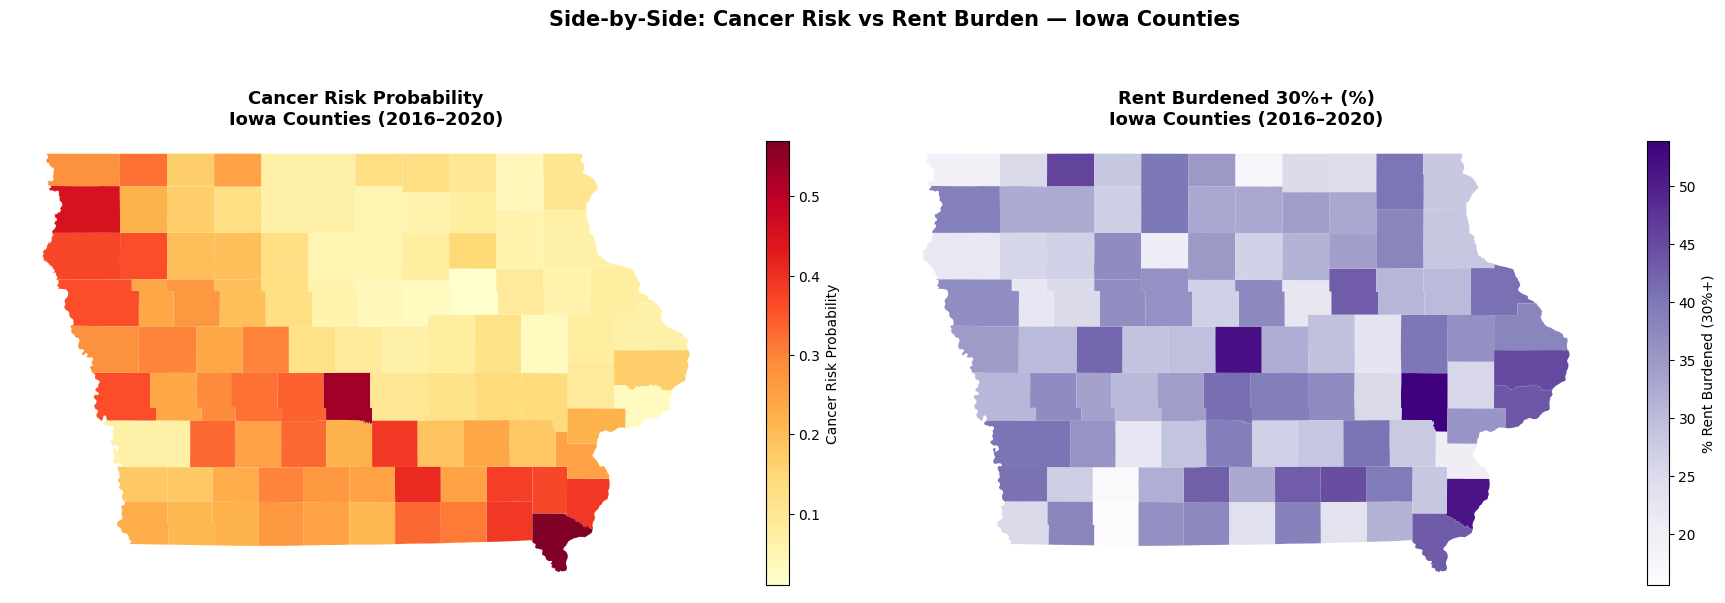

/tmp/ipykernel_2756/2832533229.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([merged_rent[c].dropna() for c in rent_vars],


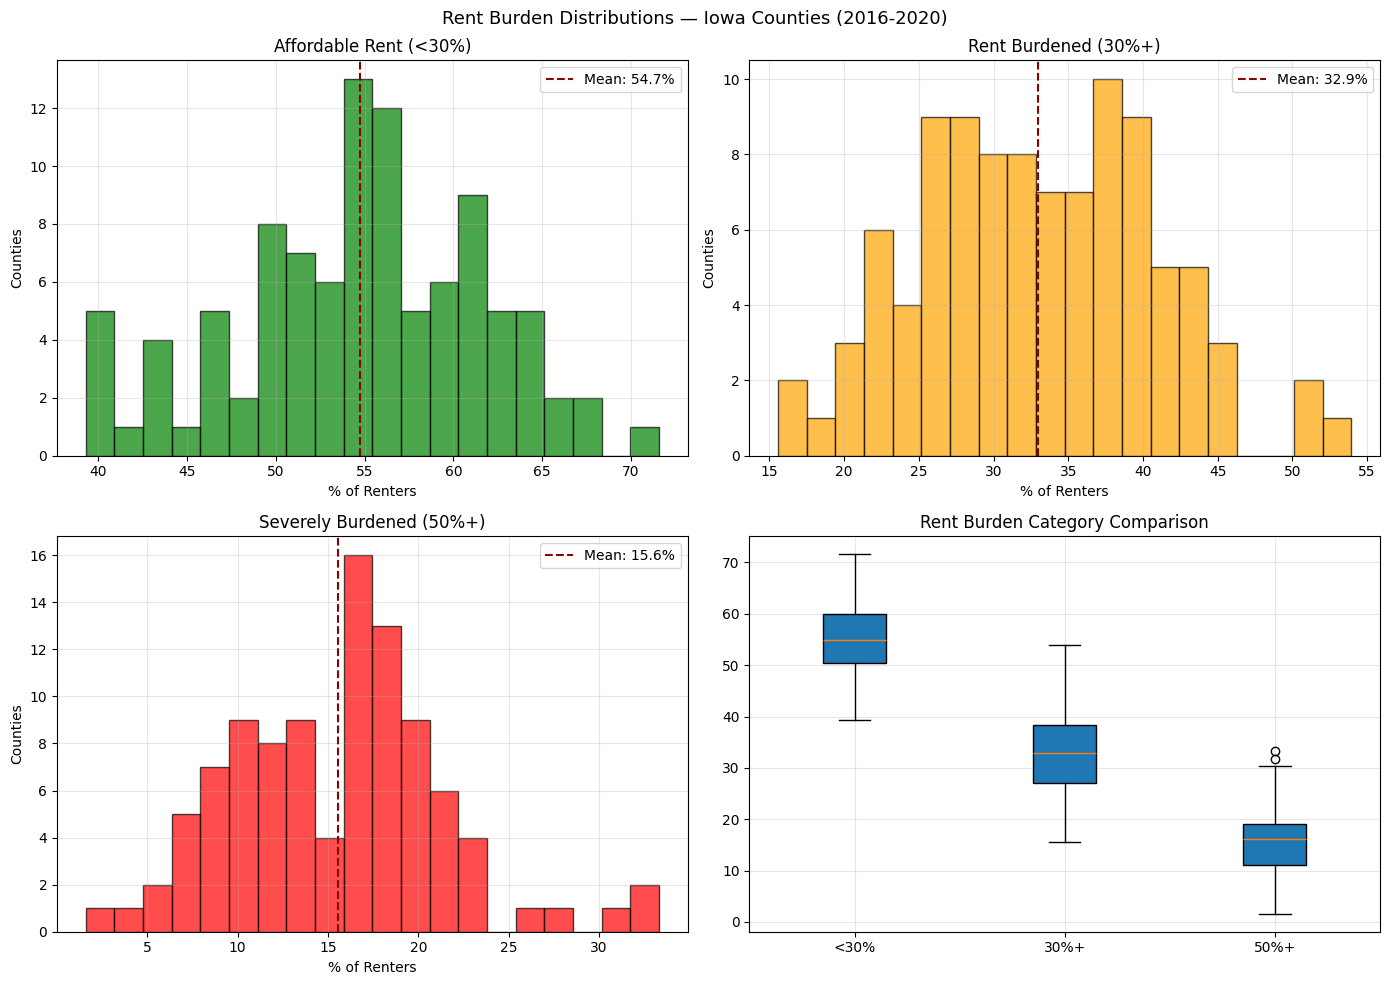

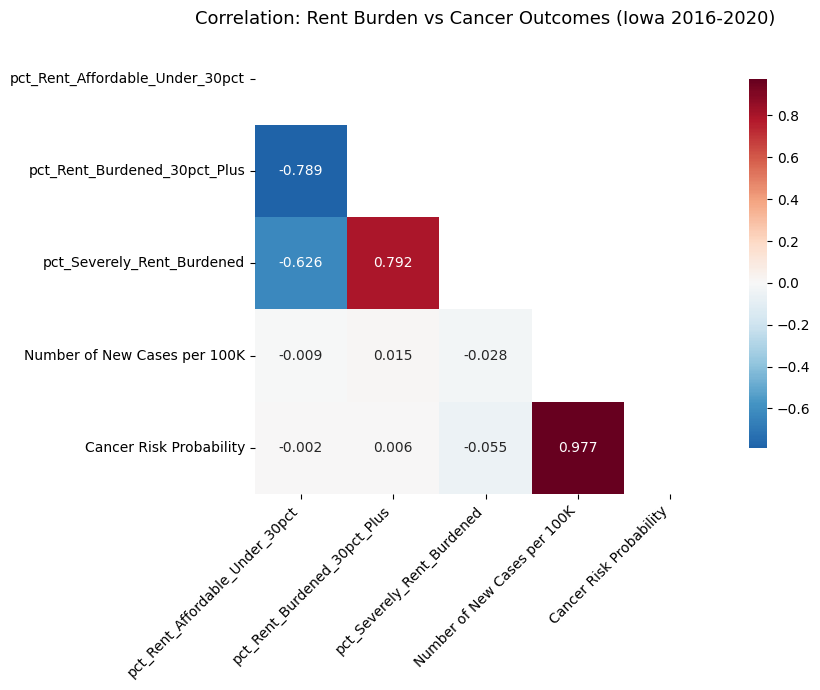

Pearson correlations with cancer outcomes:
  pct_Rent_Affordable_Under_30pct vs Number of New Cases per 100K: r=-0.009, p=0.932 
  pct_Rent_Affordable_Under_30pct vs Cancer Risk Probability: r=-0.002, p=0.981 
  pct_Rent_Burdened_30pct_Plus vs Number of New Cases per 100K: r=0.015, p=0.885 
  pct_Rent_Burdened_30pct_Plus vs Cancer Risk Probability: r=0.006, p=0.955 
  pct_Severely_Rent_Burdened vs Number of New Cases per 100K: r=-0.028, p=0.785 
  pct_Severely_Rent_Burdened vs Cancer Risk Probability: r=-0.055, p=0.591 


In [4]:
# ── Choropleth: Cancer Risk vs Rent Burden ────────────────────────────────────
gdf      = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2022/COUNTY/tl_2022_us_county.zip")
iowa_gdf = gdf[gdf['STATEFP']=='19'].copy()
iowa_gdf['NAME'] = iowa_gdf['NAME'].str.strip()
map_df   = iowa_gdf.merge(merged_rent, left_on='NAME', right_on='County', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
map_df.plot(column='Cancer Risk Probability', ax=axes[0], legend=True, cmap='YlOrRd',
            missing_kwds={'color':'lightgrey'}, legend_kwds={'label':'Cancer Risk Probability','shrink':0.7})
axes[0].set_title('Cancer Risk Probability\nIowa Counties (2016–2020)', fontsize=13, fontweight='bold')
axes[0].axis('off')
map_df.plot(column='pct_Rent_Burdened_30pct_Plus', ax=axes[1], legend=True, cmap='Purples',
            missing_kwds={'color':'lightgrey'}, legend_kwds={'label':'% Rent Burdened (30%+)','shrink':0.7})
axes[1].set_title('Rent Burdened 30%+ (%)\nIowa Counties (2016–2020)', fontsize=13, fontweight='bold')
axes[1].axis('off')
plt.suptitle('Side-by-Side: Cancer Risk vs Rent Burden — Iowa Counties', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Distributions + box comparison ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax,(col,color,title) in zip(axes.flat[:3],[
    ('pct_Rent_Affordable_Under_30pct','green', 'Affordable Rent (<30%)'),
    ('pct_Rent_Burdened_30pct_Plus',   'orange','Rent Burdened (30%+)'),
    ('pct_Severely_Rent_Burdened',     'red',   'Severely Burdened (50%+)')]):
    ax.hist(merged_rent[col].dropna(), bins=20, color=color, edgecolor='black', alpha=0.7)
    ax.axvline(merged_rent[col].mean(), color='darkred', linestyle='--',
               label=f"Mean: {merged_rent[col].mean():.1f}%")
    ax.set_title(title); ax.set_xlabel('% of Renters'); ax.set_ylabel('Counties')
    ax.legend(); ax.grid(True, alpha=0.3)
axes[1,1].boxplot([merged_rent[c].dropna() for c in rent_vars],
                   labels=['<30%','30%+','50%+'], patch_artist=True)
axes[1,1].set_title('Rent Burden Category Comparison'); axes[1,1].grid(True, alpha=0.3)
plt.suptitle('Rent Burden Distributions — Iowa Counties (2016-2020)', fontsize=13)
plt.tight_layout(); plt.show()

# ── Correlation heatmap + printed correlations ────────────────────────────────
corr_data = merged_rent[rent_vars + cancer_vars].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_data, mask=np.triu(np.ones_like(corr_data,dtype=bool)),
            annot=True, cmap='RdBu_r', center=0, square=True, fmt='.3f',
            cbar_kws={'shrink':.8}, ax=ax)
ax.set_title('Correlation: Rent Burden vs Cancer Outcomes (Iowa 2016-2020)', fontsize=13)
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

print("Pearson correlations with cancer outcomes:")
for rv in rent_vars:
    for cv in cancer_vars:
        clean = merged_rent[[rv,cv]].dropna()
        r, p  = pearsonr(clean[rv], clean[cv])
        print(f"  {rv} vs {cv}: r={r:.3f}, p={p:.3f} {'(significant)' if p<0.05 else ''}")


## 4. Scatter plots, violin plots and histograms

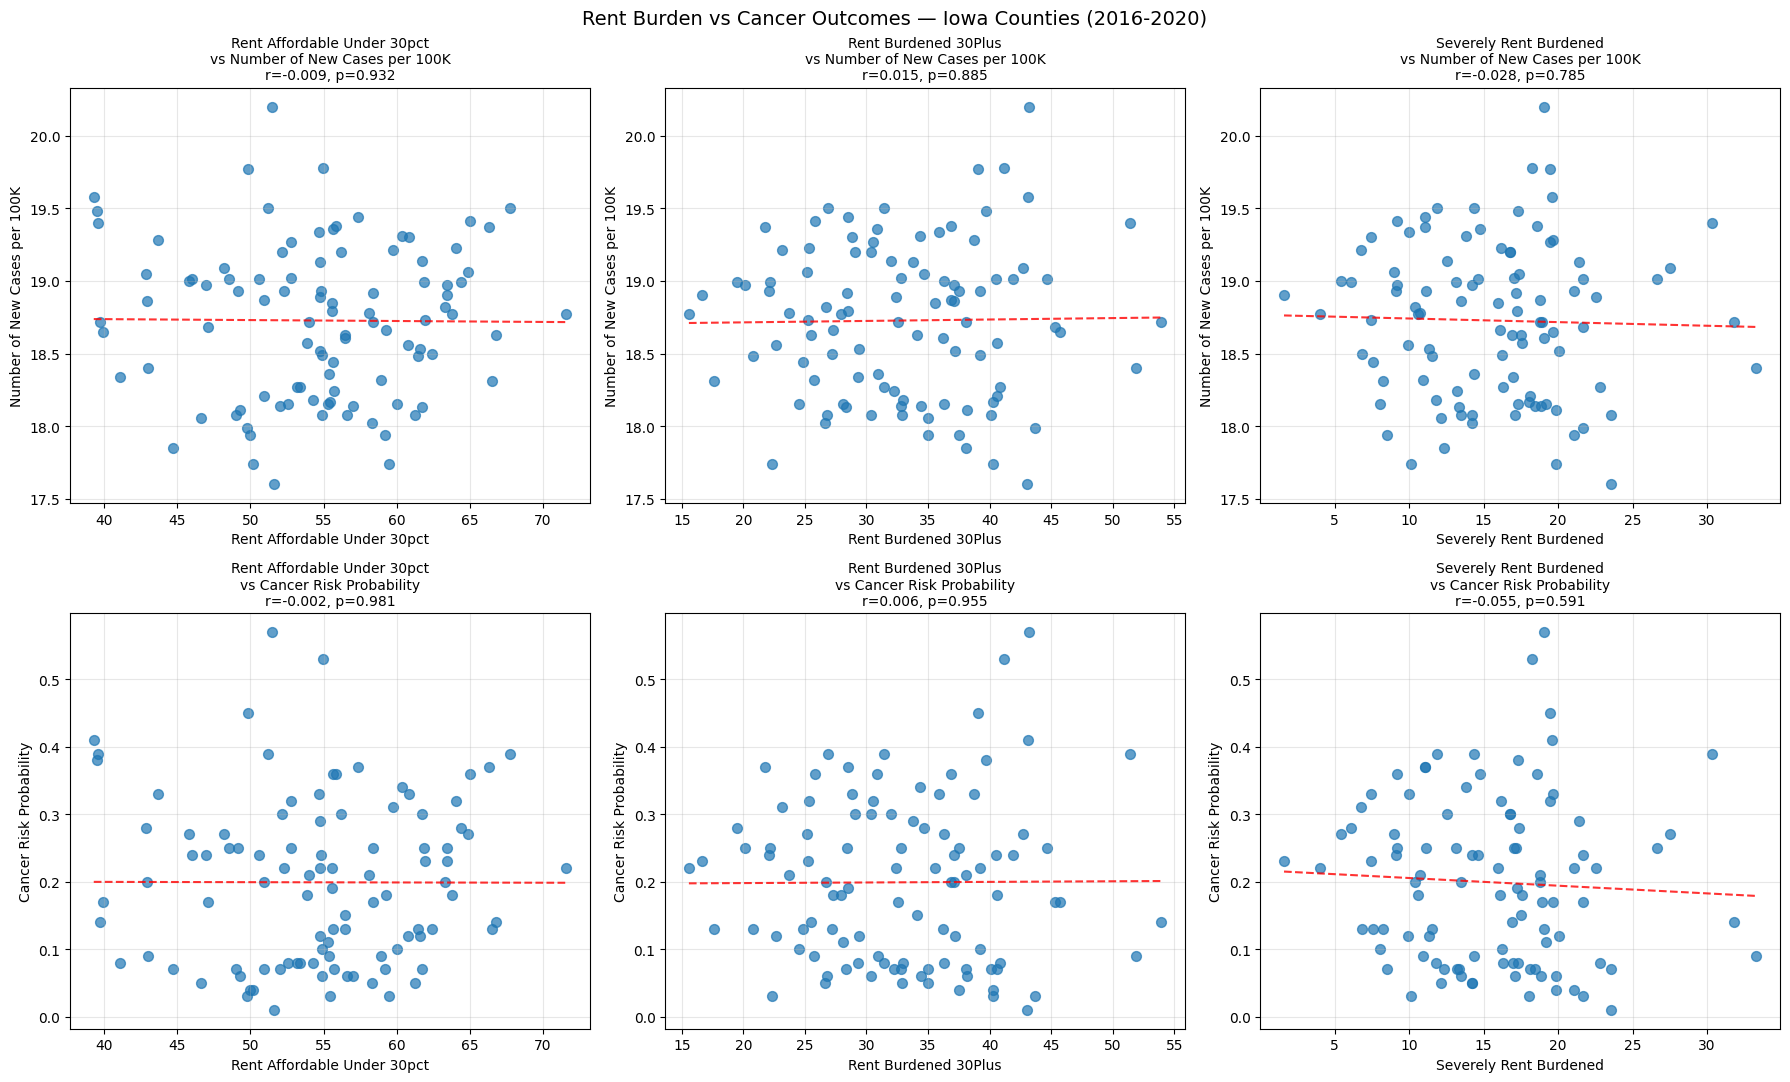

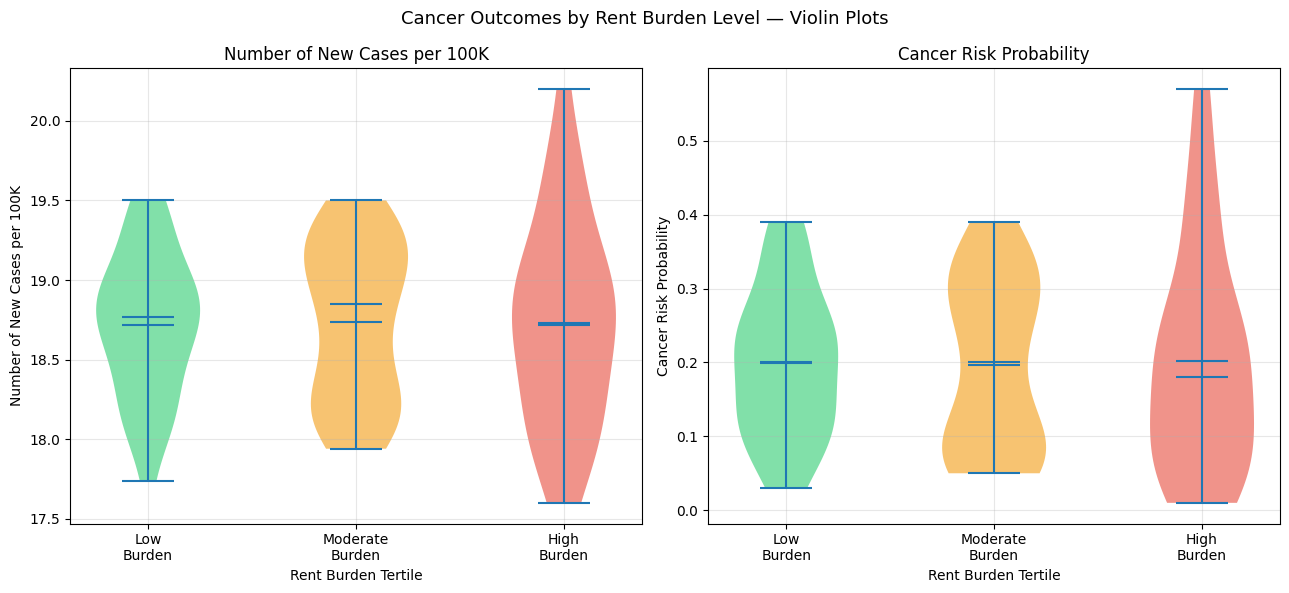

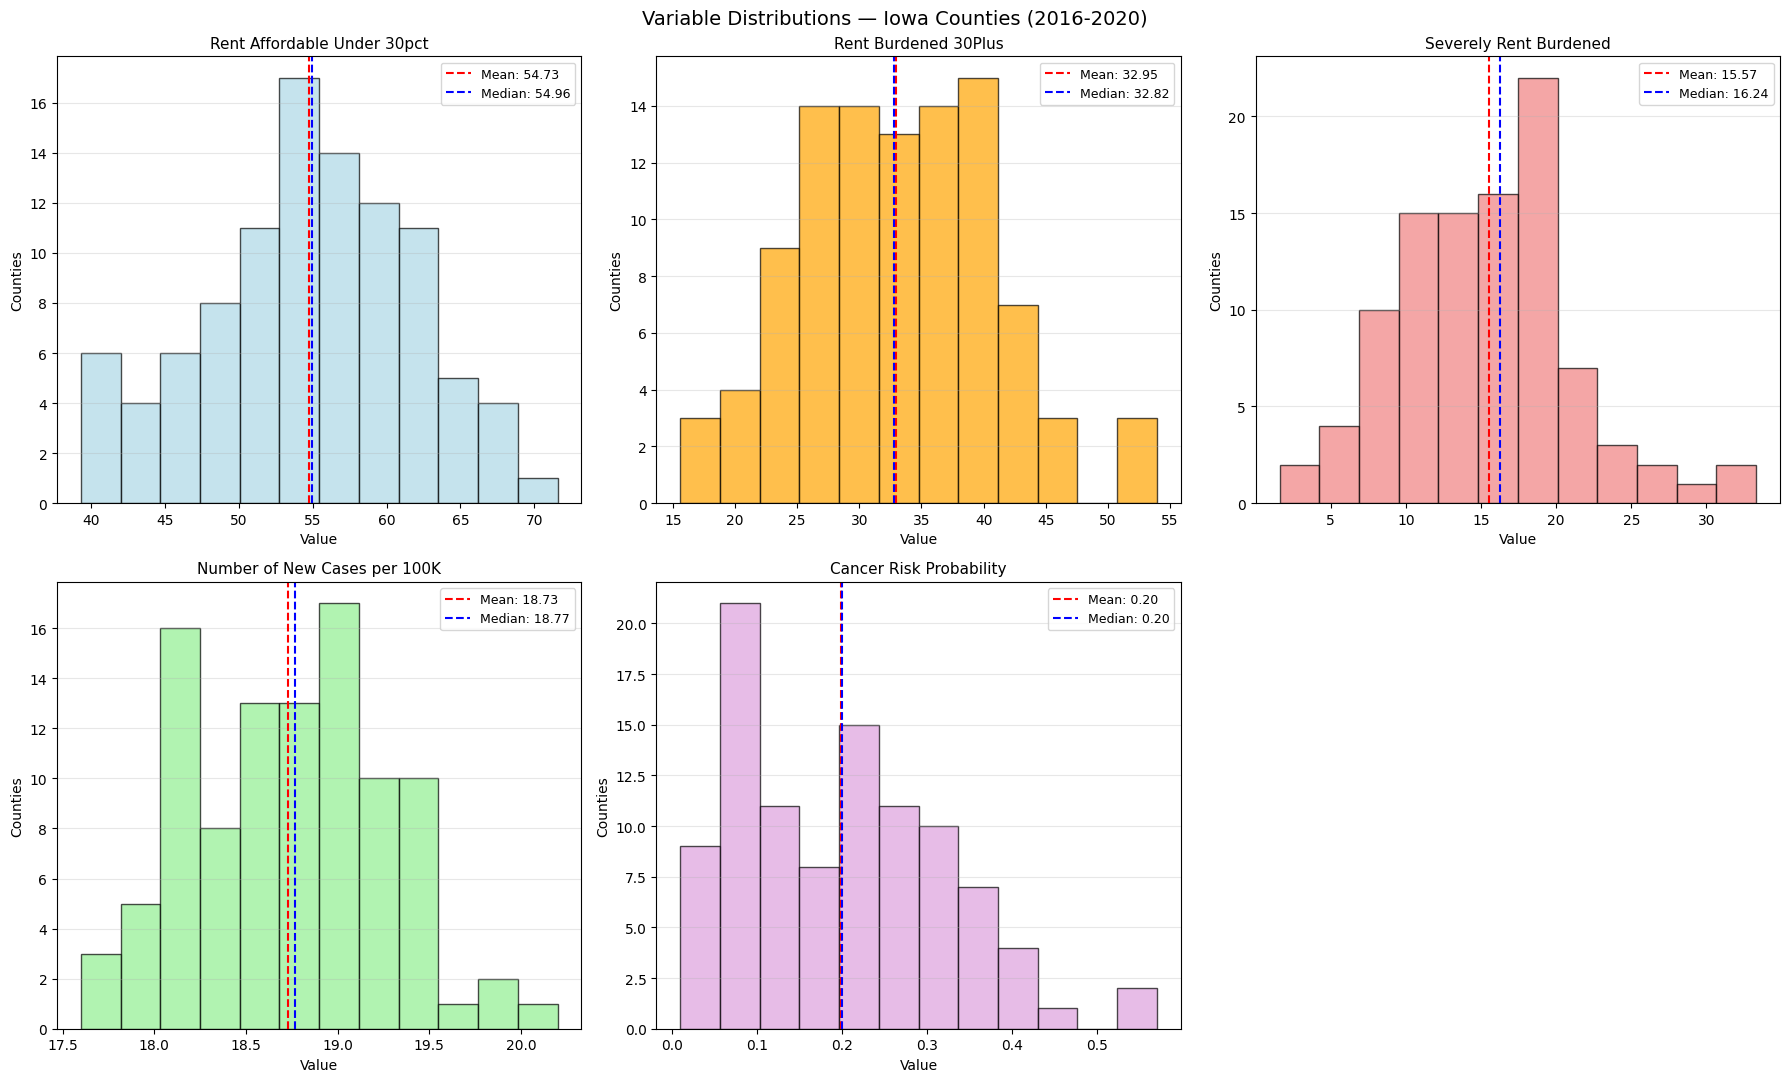

In [5]:
# ── Scatter plots with regression lines ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Rent Burden vs Cancer Outcomes — Iowa Counties (2016-2020)', fontsize=14)
for i, cv in enumerate(cancer_vars):
    for j, rv in enumerate(rent_vars):
        ax    = axes[i,j]
        clean = merged_rent[[rv,cv]].dropna()
        xs    = np.sort(clean[rv].values)
        ax.scatter(clean[rv], clean[cv], alpha=0.7, s=50)
        ax.plot(xs, np.poly1d(np.polyfit(clean[rv],clean[cv],1))(xs), 'r--', alpha=0.8)
        r, p  = pearsonr(clean[rv], clean[cv])
        ax.set_title(f'{rv.replace("pct_","").replace("_"," ")}\nvs {cv}\nr={r:.3f}, p={p:.3f}', fontsize=10)
        ax.set_xlabel(rv.replace('pct_','').replace('_',' ')); ax.set_ylabel(cv)
        ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Violin plots by rent burden tertile ───────────────────────────────────────
# FIX: use a temp column and drop after plotting to avoid polluting the dataframe
tertile_labels = ['Low\nBurden','Moderate\nBurden','High\nBurden']
tertiles = pd.qcut(merged_rent['pct_Rent_Burdened_30pct_Plus'], q=3, labels=tertile_labels)
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, col in zip(axes, ['Number of New Cases per 100K','Cancer Risk Probability']):
    groups = [merged_rent[tertiles == t][col].dropna() for t in tertile_labels]
    parts  = ax.violinplot(groups, positions=[1,2,3], showmedians=True, showmeans=True)
    for pc,c in zip(parts['bodies'],['#2ecc71','#f39c12','#e74c3c']): pc.set_facecolor(c); pc.set_alpha(0.6)
    ax.set_xticks([1,2,3]); ax.set_xticklabels(tertile_labels)
    ax.set_ylabel(col); ax.set_xlabel('Rent Burden Tertile'); ax.grid(True, alpha=0.3); ax.set_title(col)
plt.suptitle('Cancer Outcomes by Rent Burden Level — Violin Plots', fontsize=13)
plt.tight_layout(); plt.show()

# ── Distribution histograms ────────────────────────────────────────────────────
all_plot_vars = rent_vars + cancer_vars
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Variable Distributions — Iowa Counties (2016-2020)', fontsize=14)
for i,(col,color) in enumerate(zip(all_plot_vars,['lightblue','orange','lightcoral','lightgreen','plum'])):
    ax   = axes[i//3][i%3]
    vals = merged_rent[col].dropna()
    ax.hist(vals, bins=12, color=color, edgecolor='black', alpha=0.7)
    ax.axvline(vals.mean(),   color='red',  linestyle='--', label=f'Mean: {vals.mean():.2f}')
    ax.axvline(vals.median(), color='blue', linestyle='--', label=f'Median: {vals.median():.2f}')
    ax.set_title(col.replace('pct_','').replace('_',' '), fontsize=11)
    ax.set_xlabel('Value'); ax.set_ylabel('Counties')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
axes[1,2].remove()
plt.tight_layout(); plt.show()


## Rent Burden vs Cancer — Key Findings

**Rent burden has no relationship with colorectal cancer outcomes in Iowa.** All six Pearson correlations are near-zero and non-significant:

| Variable | vs AAR | vs Cancer Risk Prob |
|---|---|---|
| Affordable rent (<30%) | r = −0.009, p = 0.932 | r = −0.002, p = 0.981 |
| Rent burdened (30%+) | r = +0.015, p = 0.885 | r = +0.006, p = 0.955 |
| Severely burdened (50%+) | r = −0.028, p = 0.785 | r = −0.055, p = 0.591 |

The scatter plots show flat regression lines with wide scatter across all three rent variables, and the violin plots show near-identical cancer outcome distributions across rent burden tertiles.

**This is itself a finding worth stating.** Iowa's housing market is comparatively affordable — most counties have 50–60% of renters paying under 30% of income on rent — and the variation that does exist does not map onto cancer burden. Rent burden and cancer prevention may require separate policy responses targeting different counties entirely.